<a href="https://colab.research.google.com/github/manyanaidu28/Week1-Data-Cleaning-Telco-Churn/blob/main/Week3_Customer_Segmentation_KMeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Load the Mall Customers dataset

url = "https://raw.githubusercontent.com/kennedykwangari/Mall-Customer-Segmentation-Data/master/Mall_Customers.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# Check dataset information

print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nBasic Statistics:")
print(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate Rows:
0

Basic Statistics:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007  

In [ ]:
# Select features for clustering

features = ['Annual Income (k$)', 'Spending Score (1-100)']

X = df[features]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Selected features:")
print(features)

print("\nScaled data shape:", X_scaled.shape)
print("\nFirst 5 scaled rows:")
print(X_scaled[:5])

Selected features:
['Annual Income (k$)', 'Spending Score (1-100)']

Scaled data shape: (200, 2)

First 5 scaled rows:
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


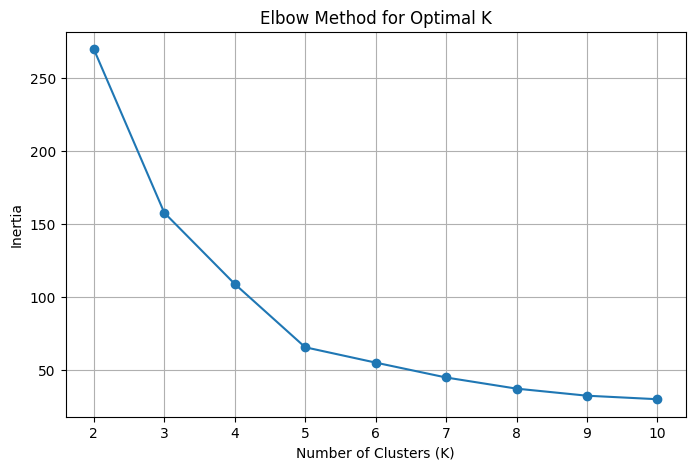

In [ ]:
# Elbow Method to find the optimal number of clusters

inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(K_range)
plt.grid(True)
plt.show()

K = 2: Silhouette Score = 0.3213
K = 3: Silhouette Score = 0.4666
K = 4: Silhouette Score = 0.4939
K = 5: Silhouette Score = 0.5547
K = 6: Silhouette Score = 0.5399
K = 7: Silhouette Score = 0.5281
K = 8: Silhouette Score = 0.4552
K = 9: Silhouette Score = 0.4571
K = 10: Silhouette Score = 0.4432


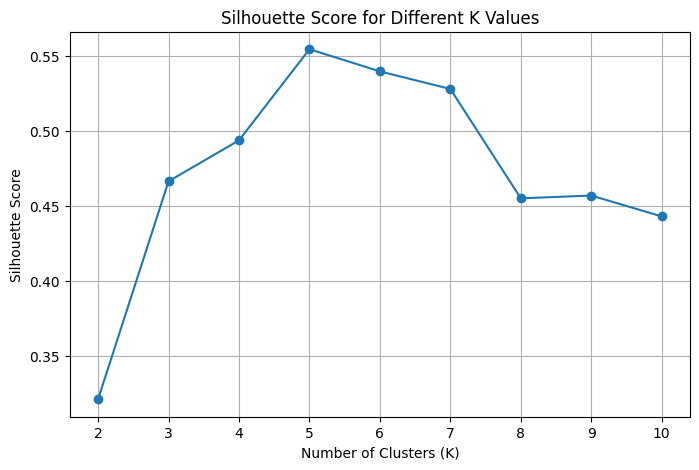

In [ ]:
# Calculate Silhouette Scores for different numbers of clusters

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)

# Display the scores
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

# Plot Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K Values')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [ ]:
# Apply K-Means clustering with 5 clusters

kmeans_final = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans_final.fit_predict(X_scaled)

print("K-Means clustering completed successfully!")

print("\nNumber of customers in each cluster:")
print(df['Cluster'].value_counts().sort_index())

K-Means clustering completed successfully!

Number of customers in each cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [ ]:
# Analyze the characteristics of each cluster

cluster_summary = df.groupby('Cluster')[[
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]].mean().round(2)

print("Average characteristics of each cluster:")
print(cluster_summary)

print("\nCluster sizes:")
print(df['Cluster'].value_counts().sort_index())

Average characteristics of each cluster:
           Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                   
0        42.72               55.30                   49.52
1        32.69               86.54                   82.13
2        25.27               25.73                   79.36
3        41.11               88.20                   17.11
4        45.22               26.30                   20.91

Cluster sizes:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [ ]:
# Display the complete cluster summary clearly

print(cluster_summary.to_string())

           Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                   
0        42.72               55.30                   49.52
1        32.69               86.54                   82.13
2        25.27               25.73                   79.36
3        41.11               88.20                   17.11
4        45.22               26.30                   20.91


In [ ]:
# Display each cluster's characteristics clearly

for cluster in cluster_summary.index:
    print(f"\nCluster {cluster}")
    print(f"Average Age: {cluster_summary.loc[cluster, 'Age']}")
    print(f"Average Annual Income: {cluster_summary.loc[cluster, 'Annual Income (k$)']}")
    print(f"Average Spending Score: {cluster_summary.loc[cluster, 'Spending Score (1-100)']}")
    print(f"Number of Customers: {df['Cluster'].value_counts()[cluster]}")


Cluster 0
Average Age: 42.72
Average Annual Income: 55.3
Average Spending Score: 49.52
Number of Customers: 81

Cluster 1
Average Age: 32.69
Average Annual Income: 86.54
Average Spending Score: 82.13
Number of Customers: 39

Cluster 2
Average Age: 25.27
Average Annual Income: 25.73
Average Spending Score: 79.36
Number of Customers: 22

Cluster 3
Average Age: 41.11
Average Annual Income: 88.2
Average Spending Score: 17.11
Number of Customers: 35

Cluster 4
Average Age: 45.22
Average Annual Income: 26.3
Average Spending Score: 20.91
Number of Customers: 23


In [ ]:
# Compact cluster summary for easy viewing

for cluster in cluster_summary.index:
    age = cluster_summary.loc[cluster, 'Age']
    income = cluster_summary.loc[cluster, 'Annual Income (k$)']
    spending = cluster_summary.loc[cluster, 'Spending Score (1-100)']
    size = df['Cluster'].value_counts()[cluster]

    print(
        f"C{cluster}: Age={age:.1f}, "
        f"Income={income:.1f}, "
        f"Spend={spending:.1f}, "
        f"Customers={size}"
    )

C0: Age=42.7, Income=55.3, Spend=49.5, Customers=81
C1: Age=32.7, Income=86.5, Spend=82.1, Customers=39
C2: Age=25.3, Income=25.7, Spend=79.4, Customers=22
C3: Age=41.1, Income=88.2, Spend=17.1, Customers=35
C4: Age=45.2, Income=26.3, Spend=20.9, Customers=23


In [ ]:
print("SPENDING SCORES")

for cluster in cluster_summary.index:
    spending = cluster_summary.loc[cluster, 'Spending Score (1-100)']
    print(f"Cluster {cluster}: {spending:.1f}")

SPENDING SCORES
Cluster 0: 49.5
Cluster 1: 82.1
Cluster 2: 79.4
Cluster 3: 17.1
Cluster 4: 20.9


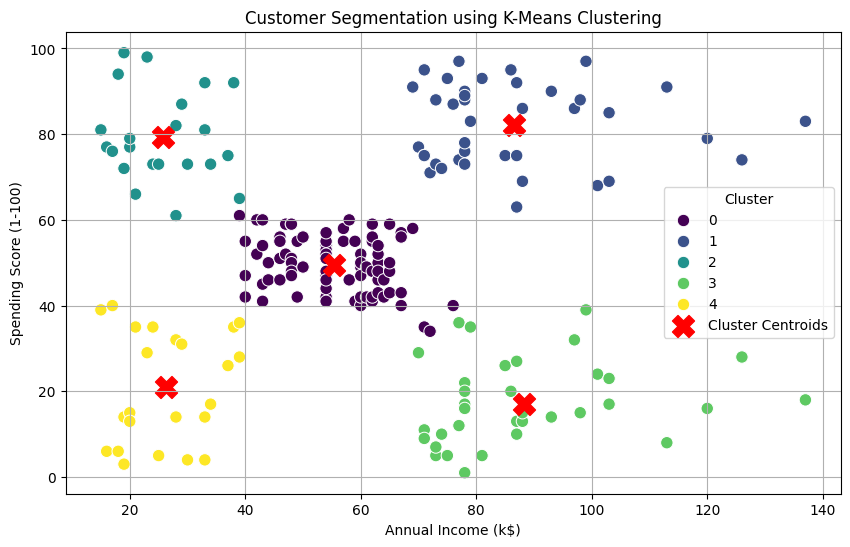

In [ ]:
# Visualize the customer clusters

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='viridis',
    s=80
)

# Plot cluster centroids
centers = scaler.inverse_transform(kmeans_final.cluster_centers_)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    s=250,
    c='red',
    marker='X',
    label='Cluster Centroids'
)

plt.title('Customer Segmentation using K-Means Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

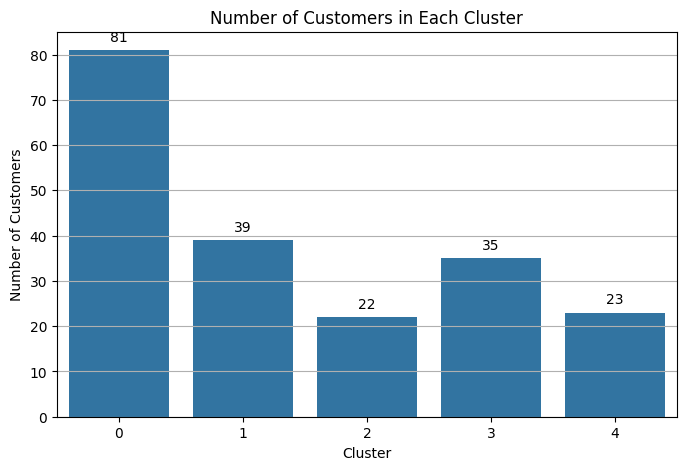

In [ ]:
# Visualize the number of customers in each cluster

cluster_counts = df['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title('Number of Customers in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')

# Add values above bars
for i, value in enumerate(cluster_counts.values):
    plt.text(i, value + 2, str(value), ha='center')

plt.grid(axis='y')
plt.show()

In [ ]:
# Create final cluster analysis table

final_cluster_analysis = df.groupby('Cluster').agg(
    Customers=('CustomerID', 'count'),
    Average_Age=('Age', 'mean'),
    Average_Income=('Annual Income (k$)', 'mean'),
    Average_Spending=('Spending Score (1-100)', 'mean')
).round(2)

print(final_cluster_analysis.to_string())

         Customers  Average_Age  Average_Income  Average_Spending
Cluster                                                          
0               81        42.72           55.30             49.52
1               39        32.69           86.54             82.13
2               22        25.27           25.73             79.36
3               35        41.11           88.20             17.11
4               23        45.22           26.30             20.91


In [ ]:
# Save the clustered dataset

output_file = "Mall_Customers_Clustered.csv"

df.to_csv(output_file, index=False)

print("Clustered dataset saved successfully!")
print("File name:", output_file)
print("Rows:", len(df))
print("Columns:", len(df.columns))

Clustered dataset saved successfully!
File name: Mall_Customers_Clustered.csv
Rows: 200
Columns: 6


In [ ]:
# Download the final clustered dataset

from google.colab import files

files.download("Mall_Customers_Clustered.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>